### Name: EDWIN SUNDAY UMANA
Data Science Internship;

Week 2, Batch D
August

DATA INSPECTION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set visualisation style
sns.set_theme(style="whitegrid")

df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')

In [3]:
print("First 10 rows of the dataset:")
display(df.head(10))

First 10 rows of the dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [4]:
# Checking the number of rows and columns
print(f"\nDataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.")


Dataset Shape: 614 rows and 13 columns.


In [5]:
# Examining dataset structure and data types
print("\nDataset Information & Data Types:")
df.info()


Dataset Information & Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
# Checking for missing values in each column
print("\n" + "="*50)
print("Missing Values per Column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) # Only show columns with missing values
print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")


Missing Values per Column:
Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64

Total missing values in dataset: 149


In [7]:
# Checking for duplicate records
duplicates = df.duplicated().sum()
print(f"\nNumber of exact duplicate rows: {duplicates}")


Number of exact duplicate rows: 0


In [9]:
# Summary statistics for numerical columns
print("\n" + "="*50)
print("Descriptive Statistics (Numerical Columns):")
display(df.describe())


Descriptive Statistics (Numerical Columns):


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [10]:
# Summary statistics for categorical (text) columns
print("\nDescriptive Statistics (Categorical Columns):")
display(df.describe(include=['object']))


Descriptive Statistics (Categorical Columns):


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


DATA CLEANING & FEATURE ENGINEERING

In [11]:
df = df.drop('Loan_ID', axis=1)

# Removing duplicates (if any exist)
df = df.drop_duplicates()



In [12]:
# Handling Missing Values
# Categorical variables: Fill with Mode (most frequent value)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

# Numerical variables: Fill with Median (robust to outliers)
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

# Credit_History: Fill with Mode (1.0 is the most frequent)
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [13]:
# Correcting Data Types
# Convert Dependents '3+' to 3 and change the whole column to integer
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# Feature Engineering (Creating new, powerful features)
# Total Income gives a better picture of household repayment capacity
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Loan-to-Income Ratio measures how much they are borrowing relative to what they earn
df['Loan_to_Income_Ratio'] = df['LoanAmount'] / df['TotalIncome']

# EMI (Equated Monthly Installment) burden approximates the monthly financial strain
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']

In [14]:
# Verifying that all missing values are gone
print("Missing values after cleaning:")
missing_check = df.isnull().sum()
print(missing_check[missing_check > 0] if missing_check.sum() > 0 else "Success! 0 missing values remaining.\n")

print(f"\nNew Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.")
print("\nFirst 5 rows after cleaning and feature engineering:")
display(df.head())

Missing values after cleaning:
Success! 0 missing values remaining.


New Dataset Shape: 614 rows and 15 columns.

First 5 rows after cleaning and feature engineering:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Loan_to_Income_Ratio,EMI
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,0.021884,0.355556
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,0.021015,0.355556
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0.022000,0.183333
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,0.024287,0.333333
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,0.023500,0.391667


OUTLIER DETECTION & HANDLING (IQR METHOD)

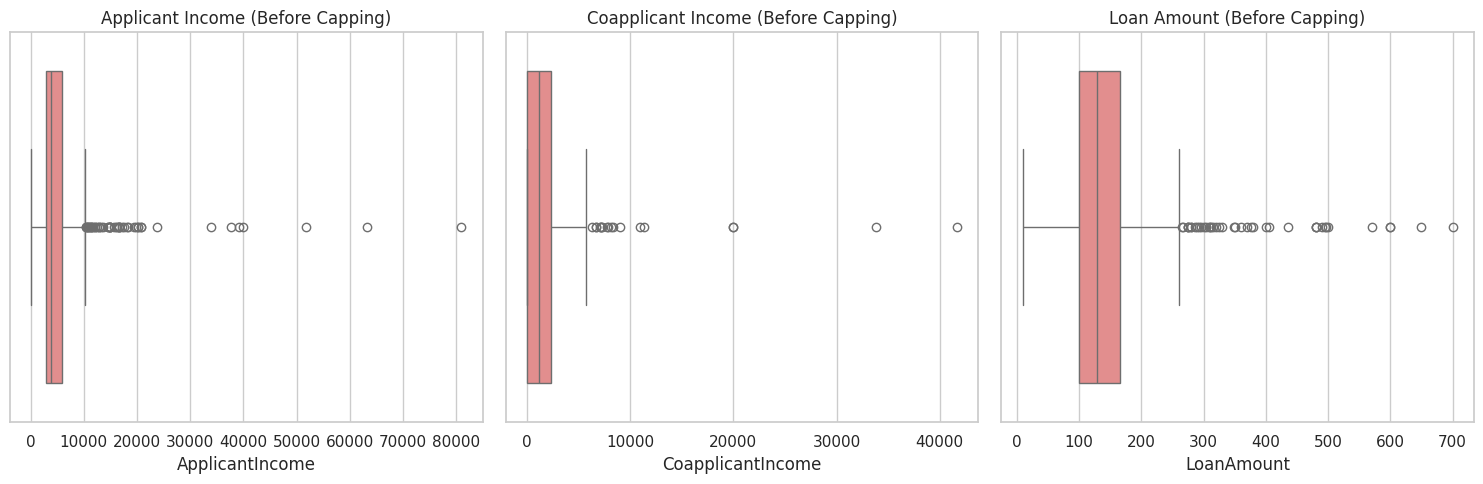

In [15]:
# Visualize outliers using Boxplots before capping
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x=df['ApplicantIncome'], color='lightcoral')
plt.title('Applicant Income (Before Capping)')

plt.subplot(1, 3, 2)
sns.boxplot(x=df['CoapplicantIncome'], color='lightcoral')
plt.title('Coapplicant Income (Before Capping)')

plt.subplot(1, 3, 3)
sns.boxplot(x=df['LoanAmount'], color='lightcoral')
plt.title('Loan Amount (Before Capping)')

plt.tight_layout()
plt.show()

In [16]:
# Cap outliers using IQR for highly skewed numerical columns
cols_to_cap = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the values (any value outside the bounds is set to the bound)
    df[col] = np.clip(df[col], lower_bound, upper_bound)

print("Outliers capped successfully using the IQR method.")

Outliers capped successfully using the IQR method.


FEATURE ENCODING

In [17]:
# Binary Encoding (Mapping to 1 and 0)
binary_mappings = {
    'Gender': {'Male': 1, 'Female': 0},
    'Married': {'Yes': 1, 'No': 0},
    'Education': {'Graduate': 1, 'Not Graduate': 0},
    'Self_Employed': {'Yes': 1, 'No': 0},
    'Loan_Status': {'Y': 1, 'N': 0} # Target Variable
}

for col, mapping in binary_mappings.items():
    df[col] = df[col].map(mapping)

# One-Hot Encoding for Nominal Categorical Variable (Property_Area)
# creating separate binary columns for Rural, Semiurban, and Urban
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=False, dtype=int)

print("Feature encoding completed.")
display(df.head())

Feature encoding completed.


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Loan_to_Income_Ratio,EMI,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849.0,0.0,128.0,360.0,1.0,1,5849.0,0.021884,0.355556,0,0,1
1,1,1,1,1,0,4583.0,1508.0,128.0,360.0,1.0,0,6091.0,0.021015,0.355556,1,0,0
2,1,1,0,1,1,3000.0,0.0,66.0,360.0,1.0,1,3000.0,0.022000,0.183333,0,0,1
3,1,1,0,0,0,2583.0,2358.0,120.0,360.0,1.0,1,4941.0,0.024287,0.333333,0,0,1
4,1,0,0,1,0,6000.0,0.0,141.0,360.0,1.0,1,6000.0,0.023500,0.391667,0,0,1


FEATURE SCALING

In [18]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target variable (y)
# It is best practice to scale features independently of the target variable
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the scaler on the features
X_scaled = scaler.fit_transform(X)

# Convert the scaled numpy array back to a Pandas DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Add the target variable back to the scaled features to create the final ML-ready dataset
ml_ready_df = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)

print("Feature scaling completed using StandardScaler.")
display(ml_ready_df.head())

Feature scaling completed using StandardScaler.


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,Loan_to_Income_Ratio,EMI,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Status
0,0.472343,-1.372089,-0.737806,0.528362,-0.392601,0.497164,-0.874587,-0.168041,0.273231,0.411733,-0.120316,-0.229045,-0.231305,-0.641478,-0.782016,1.428147,1
1,0.472343,0.728816,0.253470,0.528362,-0.392601,-0.013767,0.054395,-0.168041,0.273231,0.411733,-0.036097,-0.328983,-0.231305,1.558899,-0.782016,-0.700208,0
2,0.472343,0.728816,-0.737806,0.528362,2.547117,-0.652632,-0.874587,-1.280462,0.273231,0.411733,-1.111808,-0.215721,-0.568521,-0.641478,-0.782016,1.428147,1
3,0.472343,0.728816,-0.737806,-1.892641,-0.392601,-0.820924,0.578025,-0.311579,0.273231,0.411733,-0.436313,0.047102,-0.274817,-0.641478,-0.782016,1.428147,1
4,0.472343,-1.372089,-0.737806,0.528362,-0.392601,0.558104,-0.874587,0.065209,0.273231,0.411733,-0.067766,-0.043308,-0.160598,-0.641478,-0.782016,1.428147,1


FEATURE SELECTION & VISUALIZATIONS

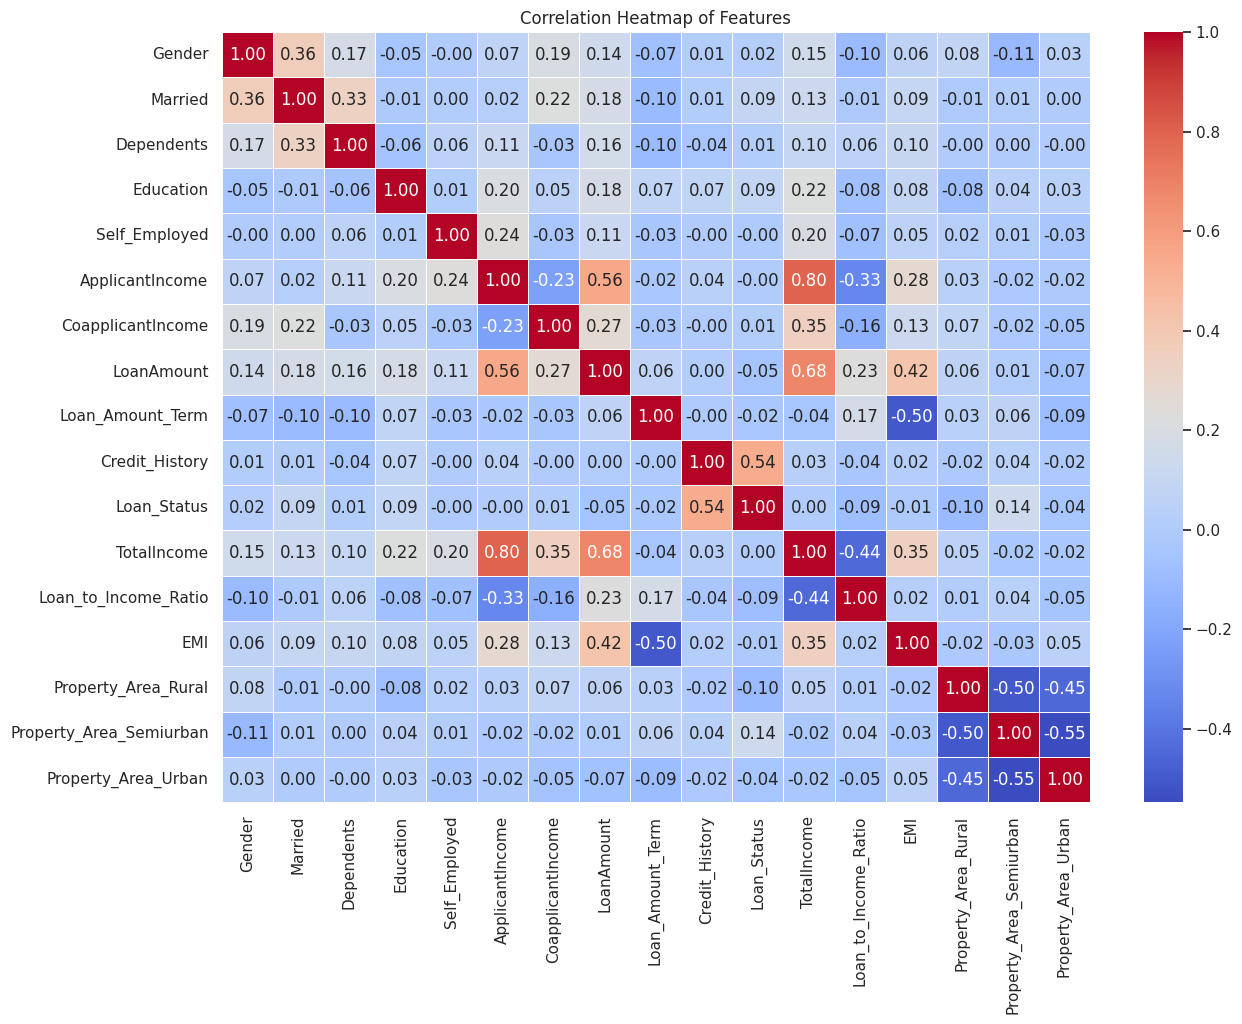

In [19]:
# Plot Correlation Heatmap (Visualization #4)
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

/tmp/ipykernel_1217/492918033.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Loan_Status'], palette='Set2')


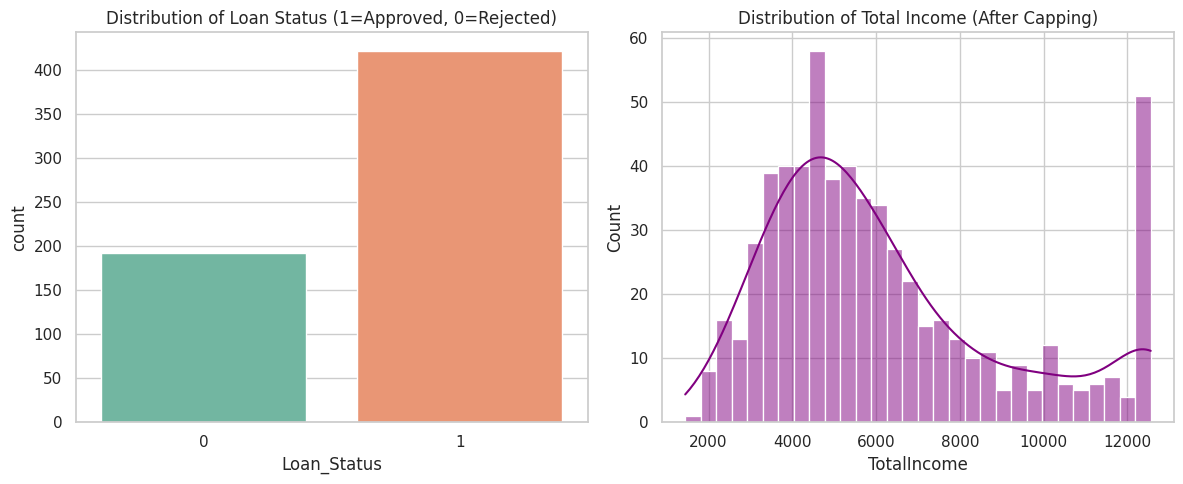

In [20]:
plt.figure(figsize=(12, 5))

# Visualization #5: Countplot of Target Variable
plt.subplot(1, 2, 1)
sns.countplot(x=df['Loan_Status'], palette='Set2')
plt.title('Distribution of Loan Status (1=Approved, 0=Rejected)')

# Visualization #6: Histogram of Total Income
plt.subplot(1, 2, 2)
sns.histplot(df['TotalIncome'], bins=30, kde=True, color='purple')
plt.title('Distribution of Total Income (After Capping)')

plt.tight_layout()
plt.show()

In [21]:
# features for the ML-ready dataset
cols_to_drop = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

# Create the ML-ready feature set
X_ml = df.drop(columns=cols_to_drop + ['Loan_Status'])
y_ml = df['Loan_Status']

# Scale the selected features
from sklearn.preprocessing import StandardScaler
scaler_ml = StandardScaler()
X_ml_scaled = scaler_ml.fit_transform(X_ml)

# Convert back to DataFrame
X_ml_scaled_df = pd.DataFrame(X_ml_scaled, columns=X_ml.columns)
ml_ready_df_final = pd.concat([X_ml_scaled_df, y_ml.reset_index(drop=True)], axis=1)

print(f"Original feature count: {df.shape[1]}")
print(f"Final ML-Ready feature count: {ml_ready_df_final.shape[1]}")
display(ml_ready_df_final.head())

Original feature count: 17
Final ML-Ready feature count: 14


,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,TotalIncome,Loan_to_Income_Ratio,EMI,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Status
0,0.472343,-1.372089,-0.737806,0.528362,-0.392601,0.273231,0.411733,-0.120316,-0.229045,-0.231305,-0.641478,-0.782016,1.428147,1
1,0.472343,0.728816,0.253470,0.528362,-0.392601,0.273231,0.411733,-0.036097,-0.328983,-0.231305,1.558899,-0.782016,-0.700208,0
2,0.472343,0.728816,-0.737806,0.528362,2.547117,0.273231,0.411733,-1.111808,-0.215721,-0.568521,-0.641478,-0.782016,1.428147,1
3,0.472343,0.728816,-0.737806,-1.892641,-0.392601,0.273231,0.411733,-0.436313,0.047102,-0.274817,-0.641478,-0.782016,1.428147,1
4,0.472343,-1.372089,-0.737806,0.528362,-0.392601,0.273231,0.411733,-0.067766,-0.043308,-0.160598,-0.641478,-0.782016,1.428147,1


In [22]:
# --- EXPORTING THE DATASETS ---

# Save the Cleaned Dataset
df.to_csv('cleaned_loan_data.csv', index=False)

# Saving the Machine Learning Ready Dataset
ml_ready_df_final.to_csv('ml_ready_loan_data.csv', index=False)

from google.colab import files

print("Downloading Cleaned Dataset...")
files.download('cleaned_loan_data.csv')

print("Downloading ML-Ready Dataset...")
files.download('ml_ready_loan_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>